# MilliRO vs T experiment

## Methods
The OPUS was placed in a 2-liter graduated glass cylinder. Inside the cylinder we put fresh milliRO water and also inserted the Amphenol thermometer with temperature and time recording on pc.
The temperature of the bath was lowered to 5 °C with OPUS turned off.
When the bath reached 5 °C (actually we know the true temperature is 5.15 °C) the Amphenol measured 5.20 °C (the difference arises because the water in the cylinder is not mixed and there is exchange with at the air-water surface).
The OPUS was turned on and it showed a temperature around 5 °C that quickly rose to 9-10 °C.
Leaving the bath at 5 °C the OPUS stabilized at about 10 °C.
We then set the bath to 25 °C with heating low and left everything on recording. At 4:30 pm local (after about 4 hours and 40 minutes) the bath reached 25 °C, while the OPUS showed almost 30 °C.

In [1]:
import pandas as pd
import numpy as np
import xarray as xr

from matplotlib import pyplot as plt

import pickle as pk
import re
import glob 

import pkl_dac_gather as op

import statsmodels.api as sm

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from matplotlib.collections import LineCollection

from sklearn.linear_model import LinearRegression as LR

In [2]:
ls ..


745F_ogsuse005b/               pkl/
74B6_ogsue009b/                renitrateexperimentmonday.zip
74B9_ogsuse010b/               Source/
74BA_ogsuse008b/               untitled folder 2/


In [3]:
MAIN_DIR = '../74B9_ogsuse010b/'

DIN = MAIN_DIR + '20250617_MQ_vs_T/'
FNS = np.sort(glob.glob(DIN + 'pkl/opus*pkl'))

FN_CAL = DIN + 'DAT/CALIBRAT.DAT'

In [4]:
# read wavelengths
wvr = pd.read_csv(MAIN_DIR + 'wv_74B9.csv').iloc[0, 1]
wv_cleaned = re.sub(r'[\[\]\n]', ' ', wvr)
wv = np.fromstring(wv_cleaned, sep=' ')

In [5]:
ds = op.mk_xr_dataset_old(FNS, wv) # read data
ds, Ts_opus = op.add_all_temps(FN_CAL, ds) # add all temperatures

ModuleNotFoundError: No module named 'numpy._core'

NameError: name 'ds' is not defined

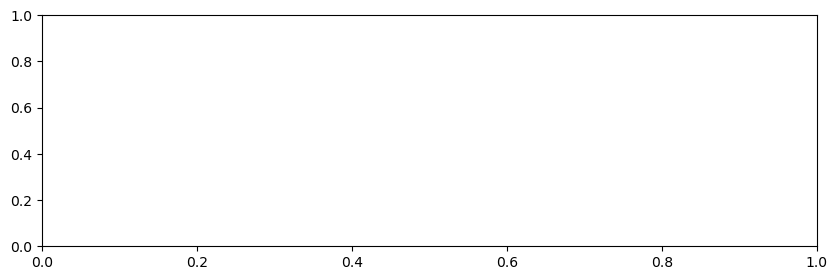

In [6]:
fig, ax = plt.subplots(1, figsize=[10,3], sharex=True)
ds['T'][::100].plot(lw=0, marker='o', ms=4, c='k', ax=ax, label='T')
ds['T_RefDiode'].plot(alpha=0.4, label='T_RefDiode')
ds['T_CPU'].plot(alpha=0.4, label='T_CPU')
ds['T_RefSpectr'].plot(alpha=0.7, label='T_RefSpectr')

ax.legend()
ax.grid(ls='--', alpha=0.4)
# ax.legend()

In [ ]:
# fig, ax = plt.subplots(4,1, figsize=[10,6], sharex=True)

# ds2plot = ds.sel(time=slice(t0, t1))

# ds2plot['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0], label=None)
# ds2plot['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1])
# ds2plot['T_CPU'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['T_RefDiode'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['T_RefSpectr'].plot(lw=0., marker='.', ms=1, alpha=0.5, ax=ax[2])
# ds2plot['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3])

# ax[2].grid(ls='--', alpha=0.4)


# # ax[3].set_xlim([pd.to_datetime('2025-06-17 11:40'), pd.to_datetime('2025-06-17 12:45')])

In [ ]:

ds2 = ds.sel(   time=slice('2025-06-17 13:15',   '2025-06-17 16:00' )  ) # this is to ensure that the temperature distribution is uniform

i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )



In [4]:
ds2

NameError: name 'ds2' is not defined

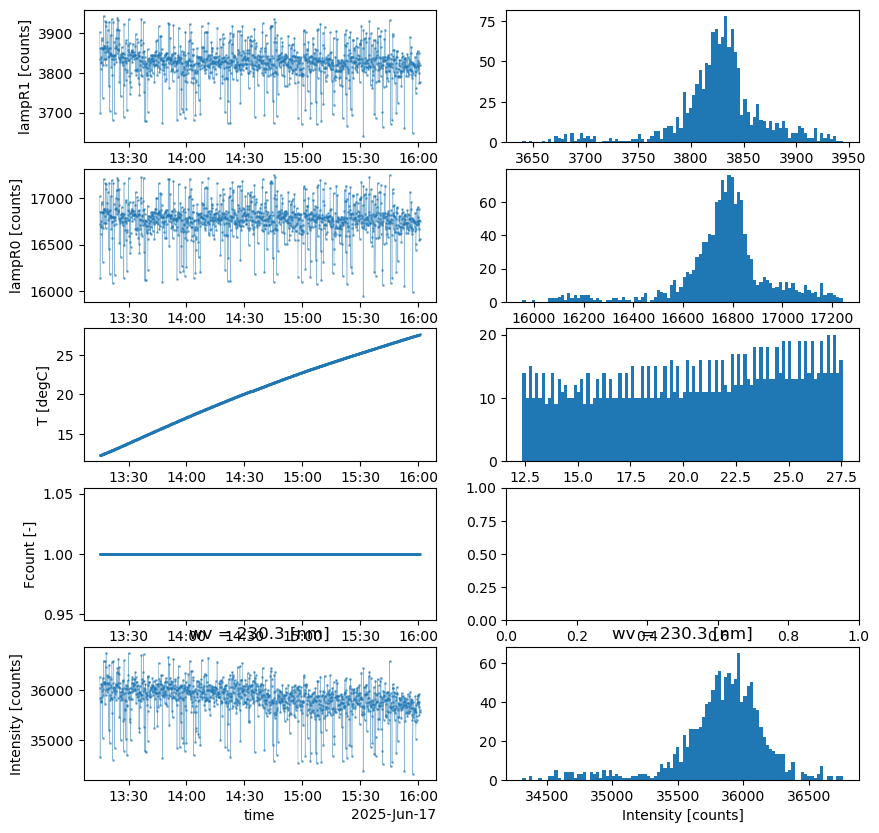

In [9]:
iwv = 50

fig, ax = plt.subplots(5,2, figsize=[10,10], sharex=False)

ds2['lampR1'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[0,0], label=None)
ax[0,0].set_xlabel('')
ds2['lampR0'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel('')
ds2['T'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[2,0])
ax[2,0].set_xlabel('')
ds2['Fcount'].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[3,0])
ax[3,0].set_xlabel('')

ds2['Intensity'][:,iwv].plot(lw=0.4, marker='.', ms=2, alpha=0.5, ax=ax[4,0])



ds2['lampR1'].plot.hist(bins=100, ax=ax[0,1]); 
ds2['lampR0'].plot.hist(bins=100, ax=ax[1,1]);
ds2['T'].plot.hist(bins=100, ax=ax[2,1]);
ds2['Intensity'][:,iwv].plot.hist(bins=100, ax=ax[4,1]);


/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/599099622.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/599099622.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/599099622.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m_lRef[ii] = lr.coef_
/var/folders/98/ls269b

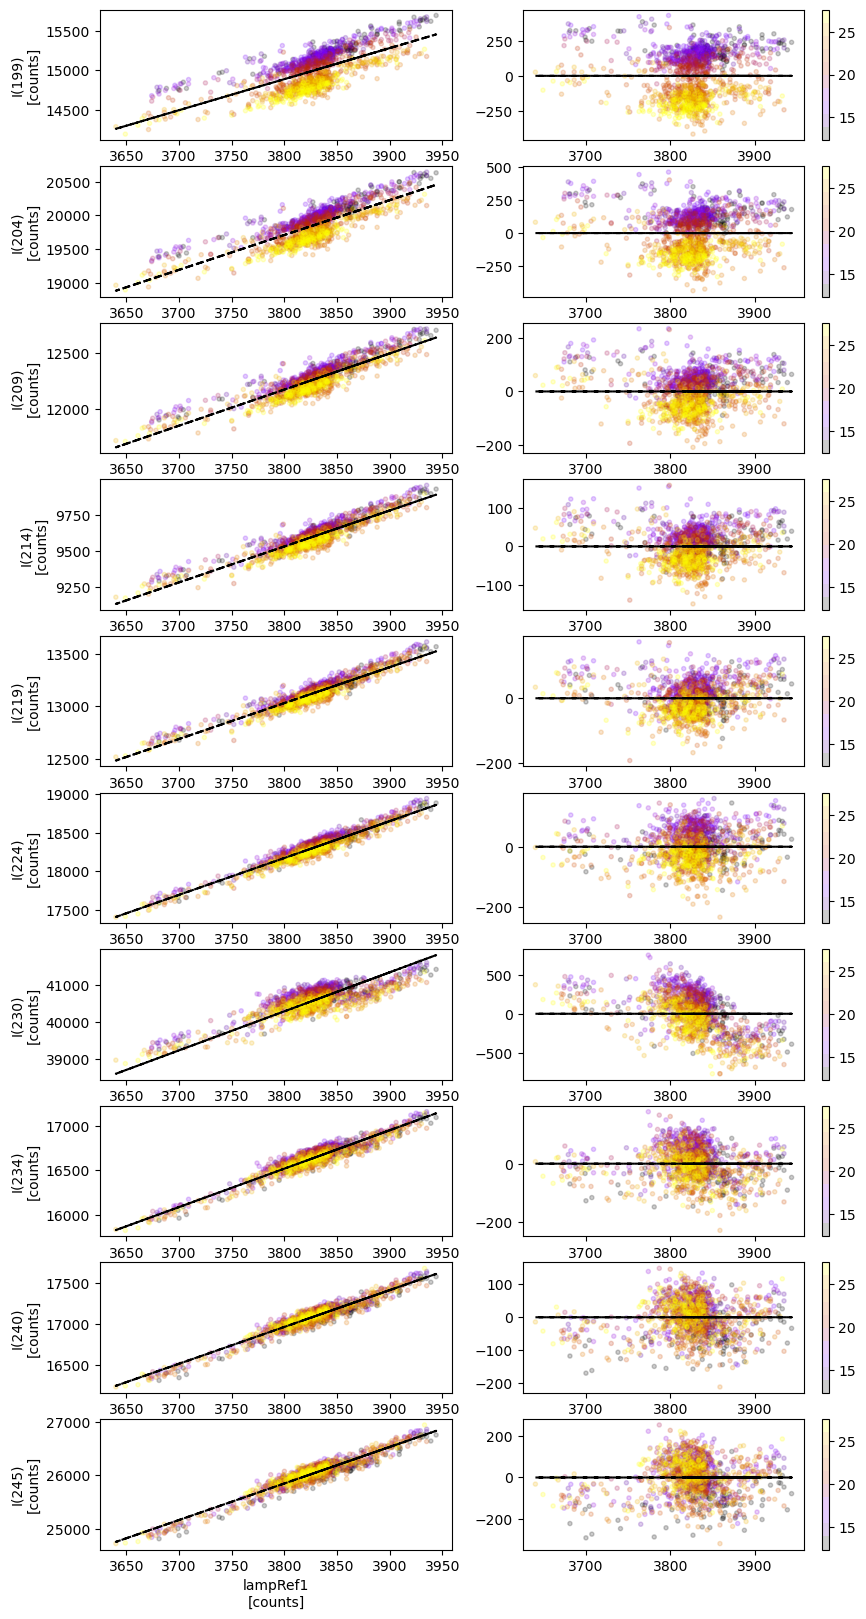

In [10]:
m_lRef = np.empty(wv[i200_255].size) * np.nan
q = np.empty(wv[i200_255].size) * np.nan

n_plots = 10
fig, ax = plt.subplots(n_plots, 2, figsize=[10,2*n_plots])



for ii,ip in enumerate(np.linspace(11, wv[i200_255].size, n_plots).astype(int)-1):
    h = ax[ii,0].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T, c=ds2['T'], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,0].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii,0].set_xlabel(f'lampRef1\n[counts]')

    # m[ii], q[ii] = np.polyfit(ds2['lampR1'], ds2['Intensity'][:,ip], 1)
    # pred = m[ii] * ds2['lampR1'] + q[ii]

    X = [   ds2['lampR1'].values,
        ]
    X = np.asarray(X)
    y = ds2['Intensity'].values[:,ip]
    
    lr = LR(fit_intercept=False)
    lr.fit(X.T, y);
    
    # m_lRef[ii], m_T[ii] = lr.coef_       
    m_lRef[ii] = lr.coef_       
    
    pred = m_lRef[ii] * ds2['lampR1'].values #+ lr.intercept_# + m_T[ii] * ds2['T']




    
    ax[ii,0].plot(ds2['lampR1'], pred, 'k--')
    
    h = ax[ii,1].scatter(ds2['lampR1'], ds2['Intensity'][:,ip].T - pred, c=ds2['T'],  #TrefDiode_i[iLT24], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('gnuplot', 10));
    
    ax[ii,1].plot(ds2['lampR1'], ds2['lampR1'][:]*0, 'k--')
    
    fig.colorbar(h)

### Plot T dependency

In [11]:
# select range of lampR1 to use to see T dependency
iLampRef = np.where( (ds2['lampR1'] >= 3800) &
                     (ds2['lampR1'] <= 3850)
                   )[0]



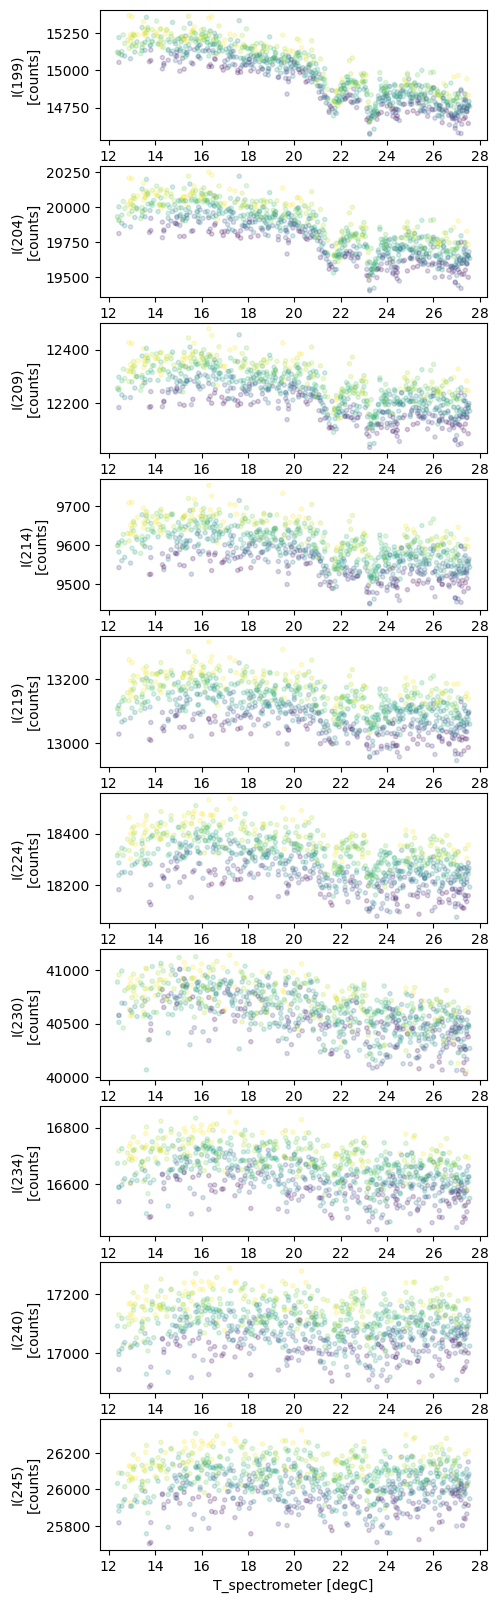

In [12]:
n_plots = 10
fig, ax = plt.subplots(n_plots, 1, figsize=[5, 2*n_plots])


for ii,ip in enumerate(np.linspace(11, wv[i200_255].size, n_plots).astype(int)-1):
    h = ax[ii].scatter(ds2['T'][iLampRef], ds2['Intensity'][iLampRef,ip].T, c=ds2['lampR1'][iLampRef], 
                         marker='.',
                         alpha=0.2, 
                         # vmin=24, vmax=25, 
                         cmap=plt.get_cmap('viridis', 10));

    # ax[ii].plot(ds2['T'][iLampRef], ds2['T'][iLampRef]*m_T[ip] + ds2['Intensity'][iLampRef[500],ip], 'k--')
    
    ax[ii].set_ylabel(f'I({wv[ip]:.0f})\n[counts]')
    ax[ii].set_xlabel(f'T_spectrometer [degC]')



In [37]:
#  fit lRef1 and T dependences
T_col = 'T'
[m_lRef_rob, m_T_rob, q_rob] = op.cmp_R_T_corr_robust(ds2, T_col, DIN, fit_intercept=False)
[m_lRef1, m_T] = op.cmp_R_T_corr(ds2, T_col, DIN, fit_intercept=False)


Text(0, 0.5, 'm_T')

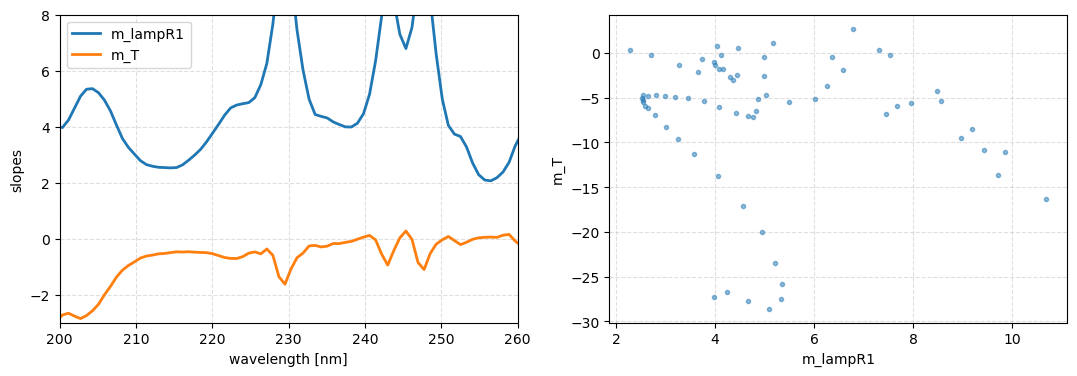

In [38]:
i200_255 = np.where( (ds2['wv'] >= 200) & (ds2['wv'] <= 255) )

fig, ax = plt.subplots(1,2, figsize=[13, 4])
# ax[0].plot(wv, m, '.-', ms=2, lw=0.5, label='m_lampR1_noT')
ax[0].plot(ds2['wv'][:], m_lRef1[:], lw=2, label='m_lampR1')
# ax[0].plot(ds2['wv'][:], m_lRef_rob[:], lw=0.5, label='m_lampR1_robust')


ax[0].plot(ds2['wv'][:], m_T[:]/10, lw=2, label='m_T')
# ax[0].plot(ds2['wv'][:], m_T_rob[:]/10, lw=0.5, label='m_T_robust')
ax[0].legend()
ax[0].grid(ls='--', alpha=0.4)
ax[0].set_xlabel('wavelength [nm]')
ax[0].set_ylabel('slopes')
ax[0].set_ylim([-3, 8])
ax[0].set_xlim([200, 260])

ax[1].plot(m_lRef1[i200_255], m_T[i200_255], '.', alpha=0.5)
ax[1].grid(ls='--', alpha=0.4)
ax[1].set_xlabel('m_lampR1')
ax[1].set_ylabel('m_T')


In [39]:
def apply_Io_corr(ds2, io, T_col, m_lRef1, m_T):
    
    Io = ds2['Intensity'][io,:]
    dR = ds2['lampR1'].values - ds2['lampR1'][io].values
    dT = ds2[T_col].values - ds2[T_col][io].values

    Io_corr  = ds2['Intensity'][io,:].values.reshape(-1,1).T +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)

    return Io_corr

In [40]:
io = 300

In [41]:
# apply correction

Io_R_not_corr = ds2['Intensity'][io,:].values.reshape(-1,1).T

Io_R_corr = apply_Io_corr(ds2, io, T_col, m_lRef1, m_T)
Io_R_corr_rob = apply_Io_corr(ds2, io, T_col, m_lRef_rob, m_T_rob)


T_not_corr  = ds2['Intensity'].values / Io_R_not_corr
A_not_corr  = -np.log10(np.asarray(T_not_corr))

T_corr   = ds2['Intensity'].values / Io_R_corr
A_corr = -np.log10(np.asarray(T_corr))

T_rob   = ds2['Intensity'].values / Io_R_corr_rob
A_corr_rob = -np.log10(np.asarray(T_rob))


WV  = np.ones([ds2['T'].size,1]) * wv.reshape(1,-1)

/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:10: RuntimeWarning: divide by zero encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_not_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:10: RuntimeWarning: invalid value encountered in log10
  A_not_corr  = -np.log10(np.asarray(T_not_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:13: RuntimeWarning: divide by zero encountered in log10
  A_corr = -np.log10(np.asarray(T_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:13: RuntimeWarning: invalid value encountered in log10
  A_corr = -np.log10(np.asarray(T_corr))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:16: RuntimeWarning: divide by zero encountered in log10
  A_corr_rob = -np.log10(np.asarray(T_rob))
/var/folders/98/ls269b9j6jq4z03kb9n9hxj40000gn/T/ipykernel_2892/3771916328.py:16: RuntimeWarning: invalid 

Text(150.97222222222223, 0.5, 'absorbance [-]')

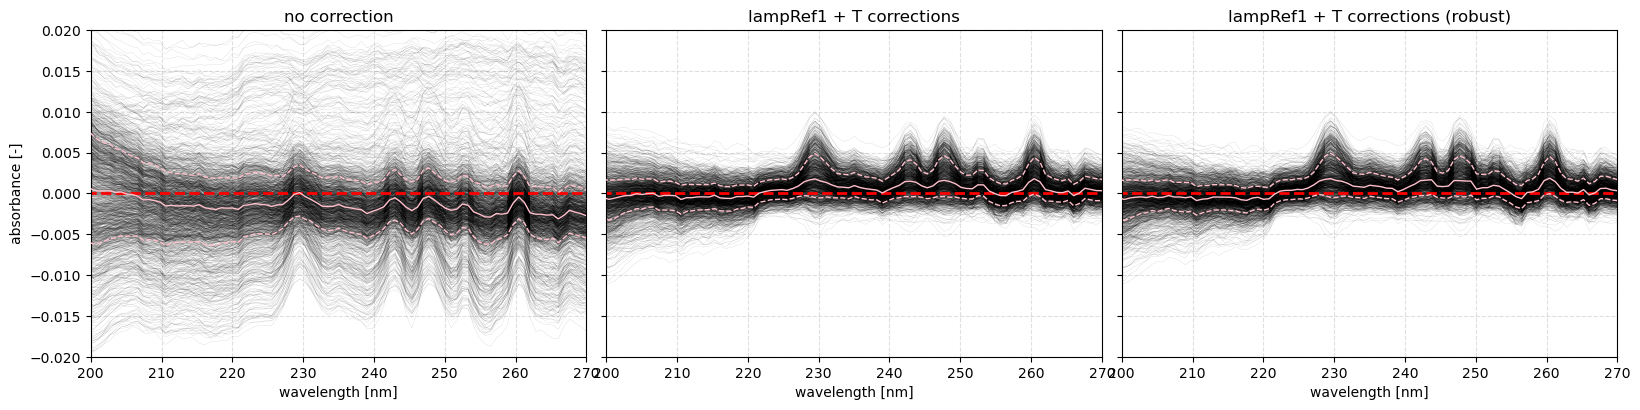

In [42]:
def make_line_collection(x, y_array, **kwargs):
    """
    Creates a LineCollection from a set of y-series sharing the same x-axis.
    x: 1D array of shape (M,)
    y_array: 2D array of shape (N, M)
    """
    # Each line segment is an array of shape (M, 2)
    segments = [np.column_stack((x, y)) for y in y_array]
    return LineCollection(segments, **kwargs)

fig, ax = plt.subplots(1, 3, figsize=[16, 4], sharex=True, sharey=True)

datasets = [
    (A_not_corr, 0),
    (A_corr, 1),
    (A_corr_rob, 2)
]

for data, i in datasets:
    # Ensure data is shaped (N, M) where M == len(wv)
    if data.shape[1] != len(wv):
        data = data.T  # transpose if needed

    lc = make_line_collection(wv, data, colors='k', linewidths=0.1, alpha=0.4)
    ax[i].add_collection(lc)
    
    ax[i].plot(wv, np.zeros_like(wv), lw=2, ls='--', c='r', alpha=1)

    median = np.nanmedian(data, axis=0)
    p16 = np.nanpercentile(data, 16, axis=0)
    p84 = np.nanpercentile(data, 84, axis=0)

    ax[i].plot(wv, median, lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p84, '--', lw=1, c='pink', zorder=60)
    ax[i].plot(wv, p16, '--', lw=1, c='pink', zorder=60)

    ax[i].autoscale()  # Important when using LineCollection

    ax[i].set_xlabel('wavelength [nm]')
    ax[i].grid(ls='--', alpha=0.4)
    
plt.tight_layout()


ax[0].set_xlim([200, 270])
ax[0].set_ylim([-0.02, 0.02])
# ax[2].set_ylim([-0.025, 0.01])


ax[0].set_title('no correction')
ax[1].set_title('lampRef1 + T corrections')
ax[2].set_title('lampRef1 + T corrections (robust)')

ax[0].set_ylabel('absorbance [-]')
# ax[0].set_ylabel('absorbance [-]')

In [43]:
def cv_rob(x):
    return np.abs((np.nanpercentile(x, 84) - np.nanpercentile(x, 16)) / 2 / np.nanpercentile(x, 50))

i200_235 = np.where((ds2['wv'] >= 200) & (ds2['wv'] <= 240))[0]

A_flat = A_not_corr[:,i200_235].flatten()
innan = np.where(~np.isnan(A_flat))[0]
print(f'{np.nanmedian(A_flat[innan]):+.4f}', f'{cv_rob(A_flat[innan]):8.2f}')


# Aflat = A[:,i200_235].flatten()
# innan = np.where(~np.isnan(Aflat))[0]
# print(f'{np.nanmedian(Aflat[innan]):+.4f}', f'{cv_rob(Aflat[innan]):8.2f}')


A__flat = A_corr[:,i200_235].flatten()
innan = np.where(~np.isnan(A__flat))[0]
print(f'{np.nanmedian(A__flat[innan]):+.4f}', f'{cv_rob(A__flat[innan]):8.2f}')


A__flat_rob = A_corr_rob[:,i200_235].flatten()
innan = np.where(~np.isnan(A__flat_rob))[0]
print(f'{np.nanmedian(A__flat_rob[innan]):+.4f}', f'{cv_rob(A__flat_rob[innan]):8.2f}')

-0.0013     3.25
+0.0001    12.78
+0.0001    19.17


In [32]:
# -0.0013     3.25
# -0.0000   174.04
# -0.0001    17.50




# i0 = 1
# +0.0006     7.31
# -0.0021     1.06
# -0.0022     1.06

# i0 = 500
# -0.0083     0.63
# +0.0017     1.71
# +0.0017     1.94

# i0 = 1000
# -0.0030     1.46
# -0.0004     4.89
# -0.0004     4.90

# i0 = 1300
# -0.0026     1.61
# -0.0006     2.77
# -0.0005     3.18

## Now create pure-water intensity spectrum at the standard $R_0$ and $T_0$ values

We define $R_0 = 3825$ counts (i.e., approximately the centre of the distribution of R values measured in this experiment) and $T_0 = 20 ^\circ$C (a temperature in the middle of the range meaured).

We then convert all intensity spectra measured to these standard values and compute the median and robust standard deviation of the resulting spectra to create a standard pure-water spectrum.

In [44]:
# define standard values
R0 = 3825 # [counts]
T0 = 20 # [degC]

In [45]:
# create and apply correction
I = ds2['Intensity'].values

# NOTE: we put the values we want to correct towards (i.e., R_0 and T_0) as first terms in the differences below
dR = R0 - ds2['lampR1'].values
dT = T0 - ds2[T_col].values

I_corr  = I    +   m_lRef1 * dR.reshape(-1,1)   +   m_T * dT.reshape(-1,1)


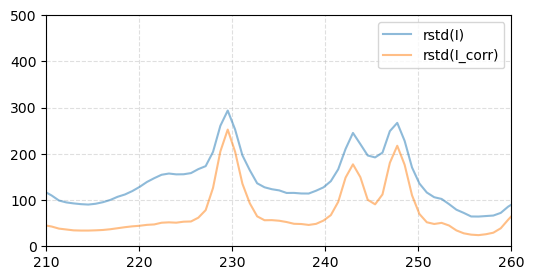

In [46]:
def prcrng(x):

    return (np.nanpercentile(x, 84, axis=0) - np.nanpercentile(x, 16, axis=0))/2



fig, ax = plt.subplots(1, figsize=[6,3])

# ax.plot(ds2['wv'], prcrng(I) / np.median(I, axis=0), alpha=0.5, label='cv(I)')
# ax.plot(ds2['wv'], prcrng(I_corr) / np.median(I_corr, axis=0), alpha=0.5, label='cv(I_corr)')
ax.plot(ds2['wv'], prcrng(I) , alpha=0.5, label='rstd(I)')
ax.plot(ds2['wv'], prcrng(I_corr), alpha=0.5, label='rstd(I_corr)')

ax.set_ylim([0, 500])
ax.set_xlim([210, 260])

ax.grid(ls='--', alpha=0.4)

ax.legend()

In [47]:
ds2 = ds2.assign(
    IpwR0T0 = ('wv', np.nanmedian(I_corr, axis=0)),
    IpwR0T0_unc = ('wv', prcrng(I_corr))
)

ds2['IpwR0T0'].assign_attrs(
    units='counts',
    name='Intensity of pure water',
    long_name='Intensity of pure water measured at standard R0 and T0 values (median spectrum)',
    R0=str(R0) + ' counts',
    T0=str(T0) + ' degrees Celcius'
);


ds2['IpwR0T0_unc'].assign_attrs(
    units='counts',
    name='Uncertainty of intensity of pure water',
    long_name='Uncertainty associated with the intensity of pure water measured at standard R0 and T0 values (prcrng spectrum)',
);

In [48]:
ds2[['IpwR0T0', 'IpwR0T0_unc']].to_netcdf(MAIN_DIR + 'Basis_spectra/Ipw.nc')

PermissionError: [Errno 13] Permission denied: '/Users/gdal/Dropbox/Project/Itineris/OPUS/Characterisations/74B9/Basis_spectra/Ipw.nc'

# To do
### - collect more data at lower T?
### - check what the other Ts were doing during during experiment ✅
### - How do we deal with the transient when the instrument switches on? (see T dependency plots when all data are included)
### - Write equations with $\epsilon_{NO3}$ and $\epsilon_{PSAL}$ corrected for ``lampRef1`` and ``T``
### - Compare slopes between different experiments (including air-only experiment)
### - Is there a dependency (in the final result) on ``io``?